In [ ]:
import random
import json
import re
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import importlib

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.metrics import confusion_matrix

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import (
    response_processing as rp,
    video_tools
)
from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as qaviz
from src.STAR_utils.visualization_tools import qa_visualization as videoviz

random.seed(6)
np.random.seed(6)

STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_gemini2.5flash_1000_OutTokens8192_20250829_22:00:00.jsonl"

VQA_FPATH = WORK_DIR / "scripts/data/aggregated_final_vqa_gemini2.5flash_longerOutTokens_20250829_18:43:00.jsonl"
GQA_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250830_14:52:00.jsonl"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


prev_analyzed = [
    "Interaction_T1_4054",
    "Interaction_T1_8913",
    "Interaction_T2_3423",
    "Interaction_T1_4115",
    "Interaction_T1_1168",
    "Interaction_T1_309",
    "Interaction_T1_4703",
    "Interaction_T1_2516",
    "Interaction_T1_8967",
    "Interaction_T1_5709",
    "Interaction_T1_2226",
    "Interaction_T1_111",
    "Interaction_T1_8274",
    "Interaction_T1_7254",
    "Interaction_T1_4221",
    #"Interaction_T1_3485",
    #"Interaction_T4_4181",
    #"Interaction_T2_1847",
]

SHOW_VIDEO = False


In [ ]:
with open(WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_test.json") as f:
    data = json.load(f)
    
len(data)


7377

Comparison between Gemma3:4b and Gemini 2.5 flash on the Graph QA task on the STSG generated by Gemini 2.5 flash

## Load GT

In [2]:
with open(STAR_VAL_SMALL, 'r') as f:
    gt_df = pd.read_json(f)

gt_df = gt_df.rename(columns={'answer': 'text'})
gt_df = gt_df.set_index('question_id')
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   object 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(6)
memory usage: 73.7+ KB


## Load predictions

In [3]:
vqa_pred_df = rp.ans_extract(VQA_FPATH, "gemma3", format="gemini")
gqa_pred_df = rp.ans_extract(GQA_FPATH, "gemma3", format="gemini")


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {"answer": "The provided Spatio-Temporal Scene Graph does not contain any information about the person holding food. Therefore, it is not possible to answer what happened after the person held the food based on the given data. None of the alternatives can be confirmed or denied in relation to the premise of \holding food.\"}.


Total answers: 1039
Answers following JSON template: 1039
Percentage following JSON template: 100.00%
Answer with a valid alternative: 987
95.00% of the total

Invalid answers: 52
Total answers: 1033
Answers following JSON template: 1033
Percentage following JSON template: 100.00%
Answer with a valid alternative: 902
87.32% of the total

Invalid answers: 131


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


## Sanity-check

### GQA sanity-check

#### Sample question

In [4]:
print(gqa_pred_df.iloc[0]["chat_history"][0]["content"])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_book
person ---- located_near ---- window
window ---- showing ---- outdoor_building_structure
doorway ---- leading_to ---- dimly_lit_room
room ---- containing ---- ornate_wooden_screen
</scene_graph>

Frame 1:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_book
person ---- raising ---- right_hand
right_hand ---- moving_towards ---- wall
person ---- looking_at ---- wall
</scene_graph>

Frame 2:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open_book
right_hand ---- touching ---- wooden_object
wooden_object ---- mounted_on ---- wall
person ---- looking_at ---- wooden_object
</scene_graph>

Frame 3:
<scene_graph>
person ---- wearing ---- green_t-shirt
person ---- holding ---- open

In [5]:
print(gqa_pred_df.iloc[0]["chat_history"][1]["content"])



1. **Question Interpretation:** The question asks what action the person is able to perform in relation to the window, based on the provided Spatio-Temporal Scene Graph.

2. **STSG Analysis:**
    *   **Frame 0:** "person ---- located_near ---- window" and "window ---- showing ---- outdoor_building_structure". This establishes the presence of a window and its state (showing the outside). There is no information about the window's functionality or the person's interaction with it.
    *   **Frames 1-6:** The person interacts with a "wooden_object" on the wall, adjusting it. The window is not mentioned.
    *   **Frame 7:** The person is looking at an "open_book". The window is not mentioned.

    The STSG explicitly states that the "person ---- located_near ---- window" in Frame 0 and that the "window ---- showing ---- outdoor_building_structure". However, it *does not provide any information* about the window's type (e.g., if it's openable), or any interaction between the person and t

In [6]:
print(gqa_pred_df.iloc[0]["chat_history"][2]["content"])



Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



In [7]:
print(gqa_pred_df.iloc[0]["chat_history"][3]["content"])



```json
{
"answer": "The provided Spatio-Temporal Scene Graph does not contain any information about the window's functionality or any interaction between the person and the window that would allow for opening, closing, holding, or lying on it. The STSG only states that a 'person ---- located_near ---- window' and 'window ---- showing ---- outdoor_building_structure'. Without any further information in the STSG about the window's attributes or the person's actions related to it, it is impossible to logically infer that the person is able to perform any of the actions listed in the alternatives. Therefore, based strictly on the provided STSG, none of the alternatives can be supported as a correct answer."
}
```


#### Unanswered questions

In [8]:
for _, row in gqa_pred_df[~gqa_pred_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])



```json
{
"answer": "The provided Spatio-Temporal Scene Graph does not contain any information about the window's functionality or any interaction between the person and the window that would allow for opening, closing, holding, or lying on it. The STSG only states that a 'person ---- located_near ---- window' and 'window ---- showing ---- outdoor_building_structure'. Without any further information in the STSG about the window's attributes or the person's actions related to it, it is impossible to logically infer that the person is able to perform any of the actions listed in the alternatives. Therefore, based strictly on the provided STSG, none of the alternatives can be supported as a correct answer."
}
```

{"answer": "Based on the provided Spatio-Temporal Scene Graph, the 'person' is consistently described as 'seated_in' a 'chair' and 'in' the 'background' from Frame 0 to Frame 10. There are no actions or changes in state attributed to the 'person' throughout the entire sequence.

### VQA sanity check

#### Sample question

In [9]:
print(vqa_pred_df.iloc[0]["chat_history"][0]["content"])



You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video and a question. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed b

In [10]:
print(vqa_pred_df.iloc[0]["chat_history"][1]["content"])



## Analysis of the Video and Answer to the Question:

### 1. Question Interpretation:
The question asks to identify an object that the person throws after walking through a doorway.

### 2. Video Analysis:
The video shows a person standing within what appears to be a doorway or the entrance to a closet.
*   **Frame 1:** The person is holding a dark-colored item, possibly a piece of clothing, with white numbers "99" visible on it. They are looking upwards and slightly to their right.
*   **Frame 2:** The person is still holding the item, adjusting their grip or moving it. The item appears to be a piece of clothing, possibly a jersey or a shirt.
*   **Frame 3:** The person's arms are in motion, suggesting they are in the process of throwing or moving the object. The object is no longer clearly visible in their hands but the motion implies release.
*   **Frame 4:** The person's arms are extended upwards and forwards, indicating a throwing motion has just been completed. A light-colored, 

In [11]:
print(vqa_pred_df.iloc[0]["chat_history"][2]["content"])



Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



In [12]:
print(vqa_pred_df.iloc[0]["chat_history"][3]["content"])



```json
{"answer": "D. The clothes."}
```


#### Unanswered questions

In [13]:
for _, row in vqa_pred_df[~vqa_pred_df['contains_answer']].iterrows():
    print(row["chat_history"][-1]["content"])



{"answer": "The question cannot be answered from the provided video frames as the premise of a person sitting at a table and then taking an object is not depicted. The first person is already seated at a desk, and the second person is standing and talking on a phone. No transition to sitting at a table or taking an object thereafter is shown. Therefore, none of the alternatives can be logically selected based on the video evidence."}

{"answer": "None of the provided alternatives (A. Sat on the floor, B. Lied on the bed, C. Put down the box, D. Put down the phone/camera) accurately describe what happened before the person opened the closet/cabinet, as the video shows the person typing on a laptop, then getting up from a chair, and walking to the cabinet."}

{"answer": "None of the provided alternatives are supported by the video evidence. The person does not interact with the laptop in any of the frames, nor do their actions suggest an intention to take, hold, open, or close it next. 

## Evals

In [14]:
vqa_pred_df.rename(columns={'answer': 'pred_text'}, inplace=True)
vqa_eval_df = gt_df.join(
    vqa_pred_df, 
    how='left' # we account also for samples without answers
)

vqa_eval_df['contains_answer'] = (
    vqa_eval_df['contains_answer'].fillna(False).astype(bool)
)
vqa_eval_df['pred_text'] = (
    vqa_eval_df['pred_text'].fillna("").astype(str)
)

rp.print_acc(vqa_eval_df[vqa_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          292        78.42%  
Sequence             275        79.64%  
Prediction           226        65.49%  
Feasibility          194        54.64%  

Average              987        71.12%  


/tmp/ipykernel_354418/3898361128.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vqa_eval_df['contains_answer'].fillna(False).astype(bool)


/home/lusha/star_code/src/response_processing.py:450: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


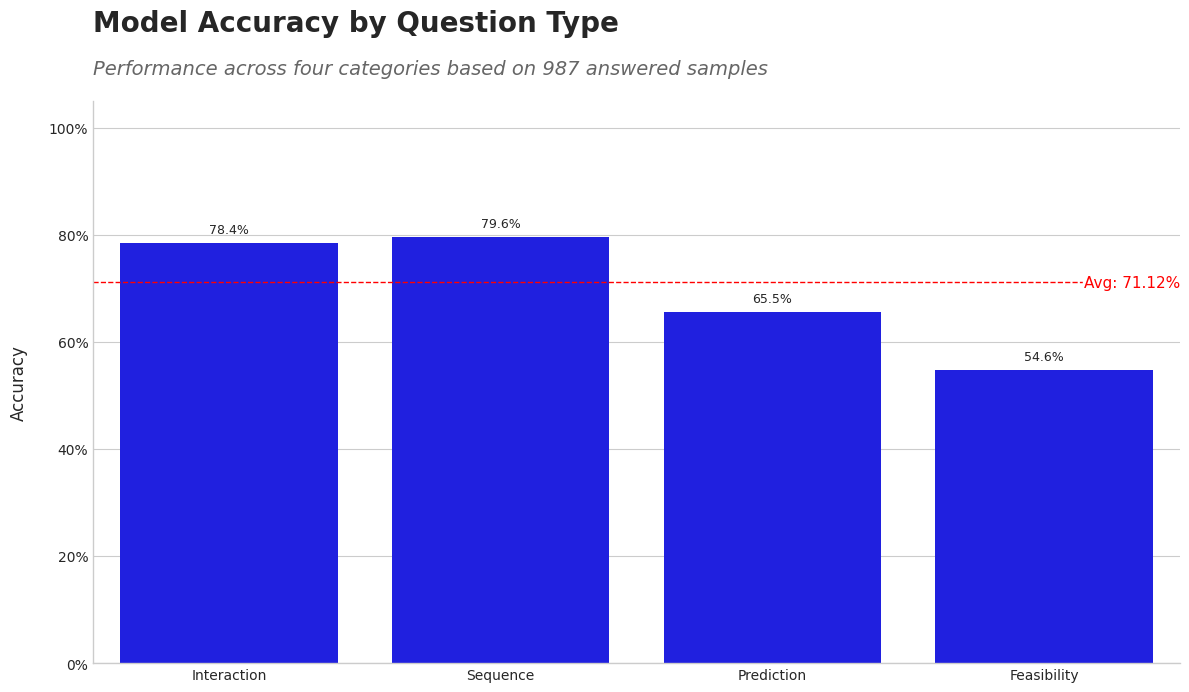

In [15]:
rp.plot_acc(vqa_eval_df[vqa_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


In [16]:
rp.print_ans_perc(vqa_eval_df[vqa_eval_df['contains_answer']], gt_df)


Question type       Total      Answered 

Interaction          298        97.99%  
Sequence             291        94.50%  
Prediction           239        94.56%  
Feasibility          220        88.18%  
Overall             1048        94.18%  


/home/lusha/star_code/src/response_processing.py:528: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


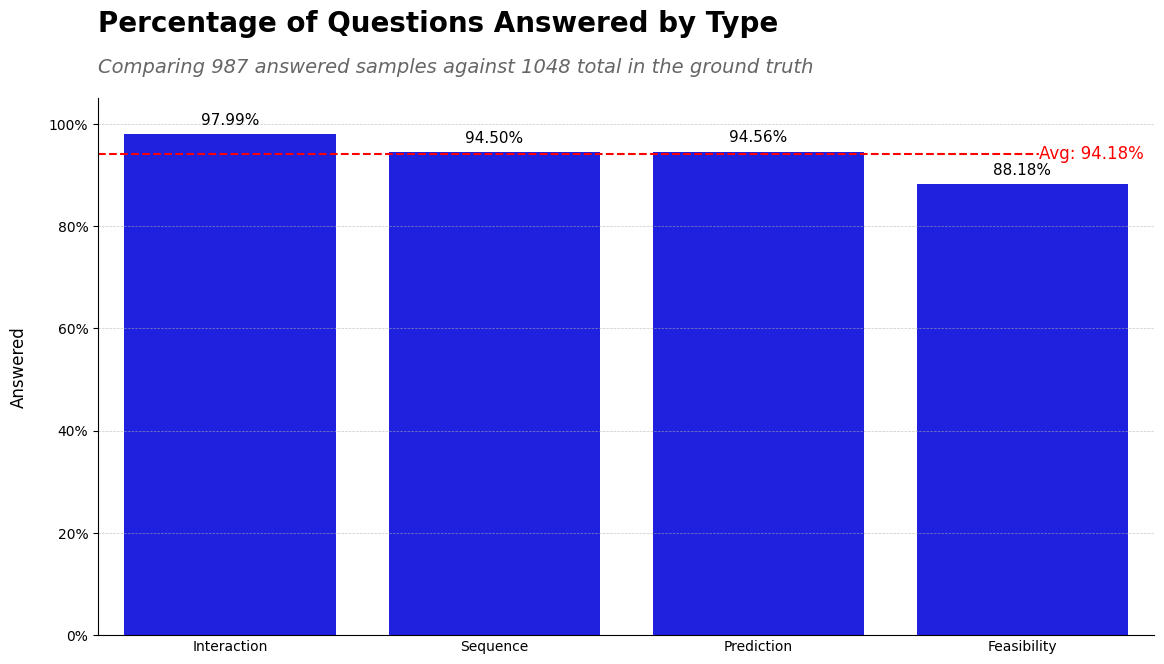

In [17]:
rp.plot_ans_perc(vqa_eval_df[vqa_eval_df['contains_answer']], gt_df)


In [18]:
gqa_pred_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gqa_eval_df = gt_df.join(
    gqa_pred_df, 
    how='left' # we account also for samples without answers
)

gqa_eval_df['contains_answer'] = (
    gqa_eval_df['contains_answer'].fillna(False).astype(bool)
)
gqa_eval_df['pred_text'] = (
    gqa_eval_df['pred_text'].fillna("").astype(str)
)

rp.print_acc(gqa_eval_df[gqa_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          266        74.44%  
Sequence             246        74.80%  
Prediction           201        62.19%  
Feasibility          189        50.26%  

Average              902        66.74%  


/tmp/ipykernel_354418/2033840570.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gqa_eval_df['contains_answer'].fillna(False).astype(bool)


/home/lusha/star_code/src/response_processing.py:450: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


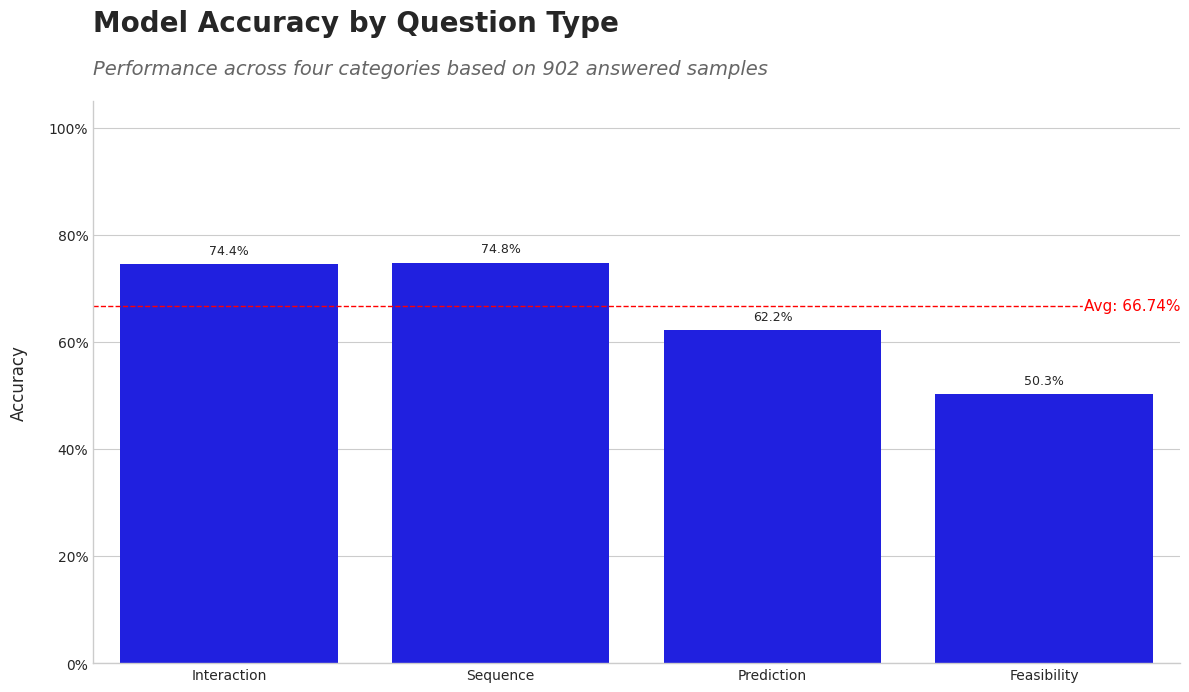

In [19]:
rp.plot_acc(gqa_eval_df[gqa_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


In [20]:
rp.print_ans_perc(gqa_eval_df[gqa_eval_df['contains_answer']], gt_df)


Question type       Total      Answered 

Interaction          298        89.26%  
Sequence             291        84.54%  
Prediction           239        84.10%  
Feasibility          220        85.91%  
Overall             1048        86.07%  


/home/lusha/star_code/src/response_processing.py:528: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


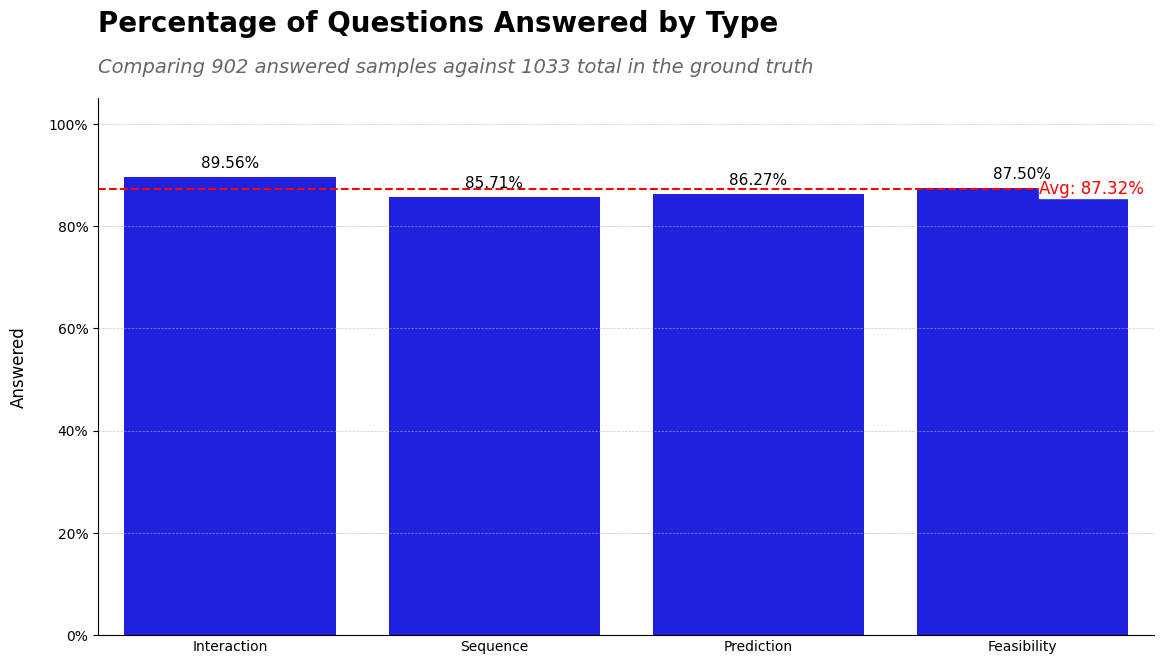

In [21]:
rp.plot_ans_perc(gqa_eval_df[gqa_eval_df['contains_answer']], gqa_pred_df)


### Accuracy NOT accounting for Missing answers

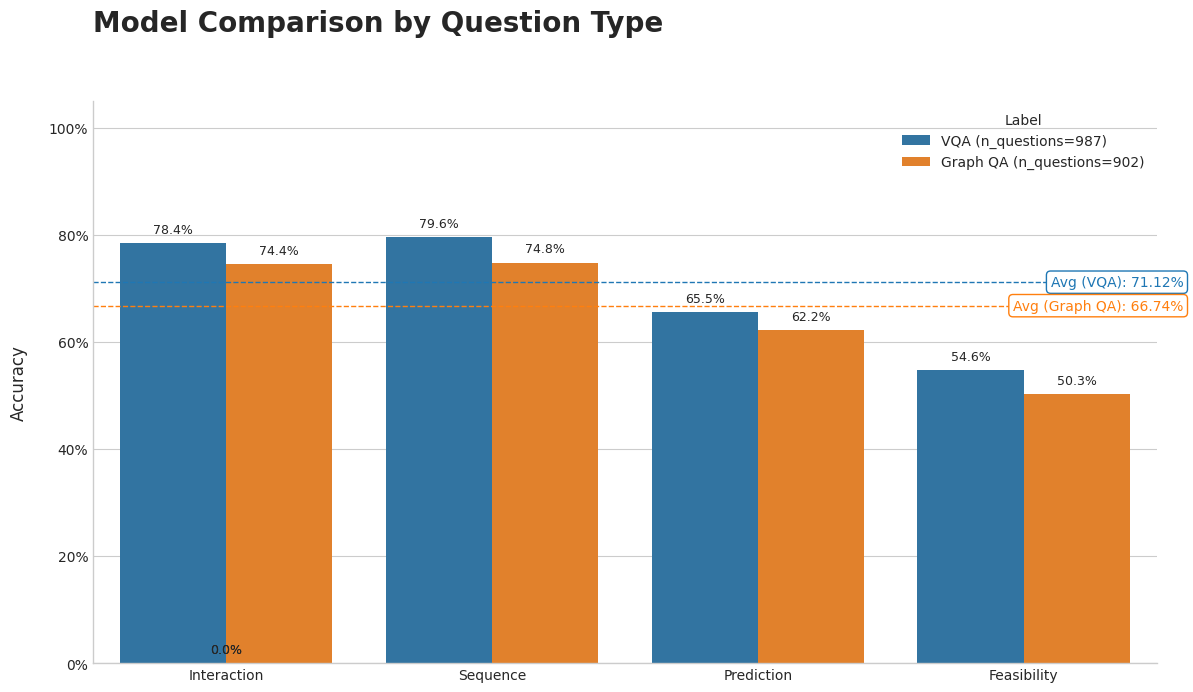

In [22]:
rp.plot_acc(
    [vqa_eval_df[vqa_eval_df['contains_answer']], gqa_eval_df[gqa_eval_df['contains_answer']]],
    labels=['VQA', 'Graph QA'], 
    acc_fn=lambda x: rp.accuracy(x, on_what='text'), )


### Accuracy accounting for Missing answers

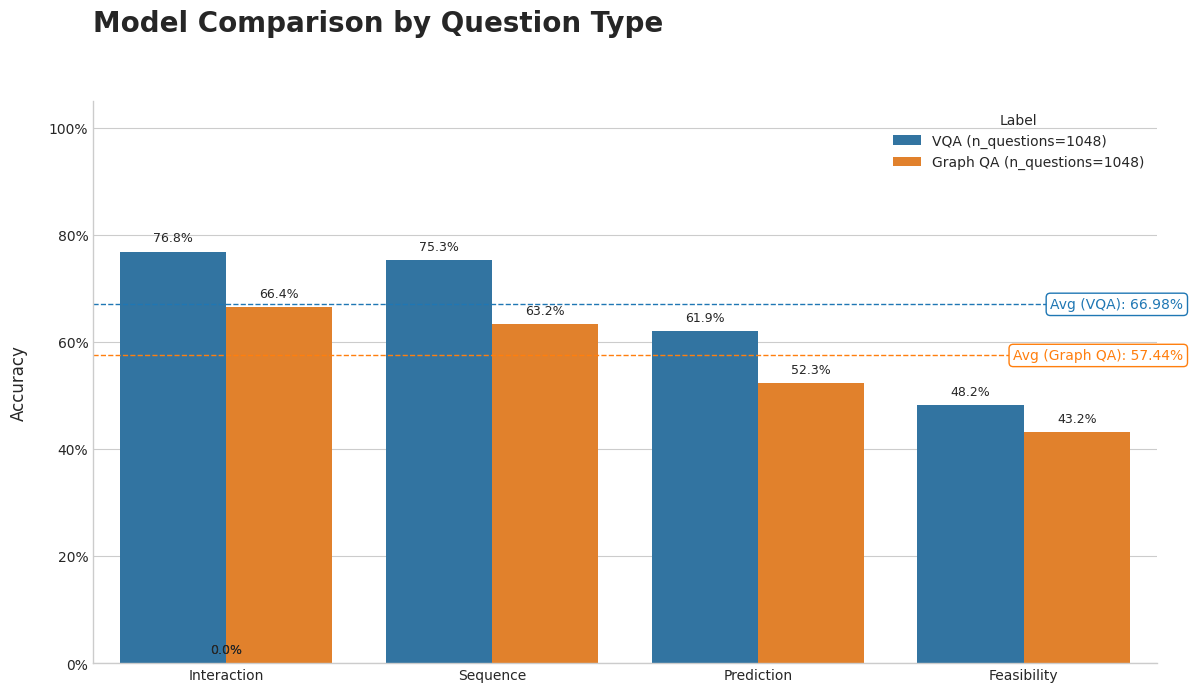

In [23]:
rp.plot_acc(
    [vqa_eval_df, gqa_eval_df],
    labels=['VQA', 'Graph QA'], 
    acc_fn=lambda x: rp.accuracy(x, on_what='text'), )


### Mismatch inspection

In [24]:
eval_df_all = gt_df.join(
    vqa_pred_df[vqa_pred_df['contains_answer']].rename(columns={'pred_text': 'pred_text1'})[['pred_text1']],
    how='inner'
).join(
    gqa_pred_df[gqa_pred_df['contains_answer']].rename(columns={'pred_text': 'pred_text2'})[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]


,question,text,pred_text1,pred_text2
Feasibility_T5_1851,Which object is the person able to close after...,the laptop.,the laptop.,the book.
Prediction_T2_450,What will the person do next with the clothes?,take.,put down.,put down.
Feasibility_T5_1670,Which object is the person able to hold after ...,the dish.,the dish.,the dish.
Sequence_T5_4571,What did the person do to the clothes after si...,put down.,put down.,put down.
Prediction_T1_499,What will the person do next?,put down the shoe.,sit on the sofa/couch.,put down the bag.
...,...,...,...,...
Interaction_T1_8913,Which object was taken by the person?,the paper/notebook.,the paper/notebook.,the paper/notebook.
Interaction_T1_8967,Which object was taken by the person?,the dish.,the dish.,the food.
Interaction_T2_1847,What did the person do with the paper/notebook?,took.,took.,put down.
Interaction_T2_3423,What did the person do with the bed?,lied on.,sat on.,sat on.


In [25]:
print(f"Questions answered by both models: \n - {eval_df_all.shape[0]}")


Questions answered by both models: 
 - 873


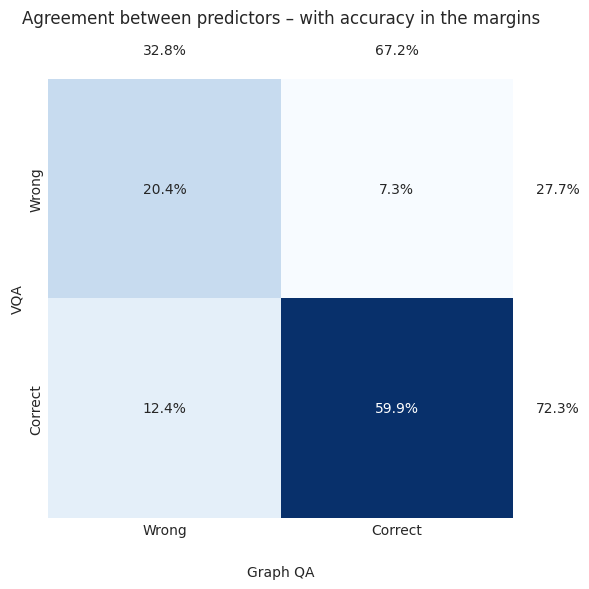

(873, 10)


In [26]:
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))  
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Graph QA', labelpad=20)
ax.set_ylabel('VQA')
ax.set_title('Agreement between predictors – with accuracy in the margins', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)


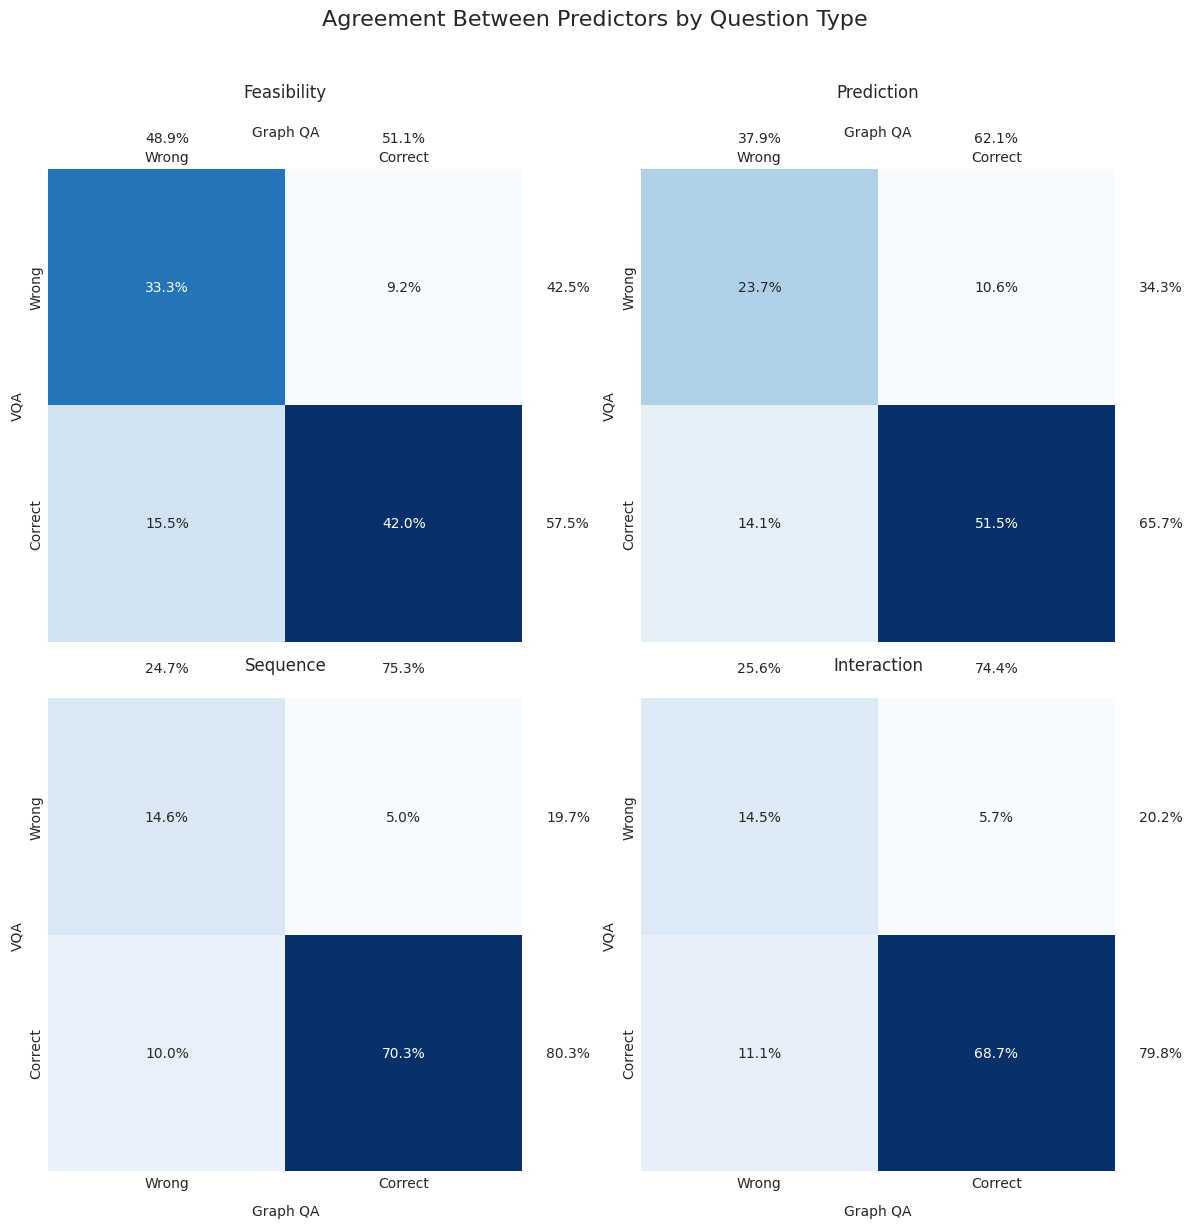

In [27]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Get unique question types
question_types = viz_df['question_type'].unique()

# Set up the plot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Agreement Between Predictors by Question Type', y=1.02, fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Calculate correctness
    pred_vqa_correct = (subset['text'] == subset['pred_text1']).astype(int).values
    pred_gg_correct = (subset['text'] == subset['pred_text2']).astype(int).values
    
    # Confusion matrix (normalized over all)
    cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')
    
    # Compute marginal sums
    row_totals = cm.sum(axis=1)
    col_totals = cm.sum(axis=0)
    total = cm.sum()
    row_pct = row_totals / total
    col_pct = col_totals / total
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                cbar=False, ax=axes[i])
    
    # Annotate row marginals
    for j, p in enumerate(row_pct):
        axes[i].text(len(labels) + 0.1, j + 0.5, f'{p:.1%}', 
                    va='center', ha='left', fontsize=10)
    
    # Annotate column marginals
    for k, p in enumerate(col_pct):
        axes[i].text(k + 0.5, -0.1, f'{p:.1%}', 
                    ha='center', va='bottom', fontsize=10)
    
    # Customize subplot
    axes[i].set_title(qtype, pad=20)
    axes[i].set_xlabel('Graph QA', labelpad=10)
    axes[i].set_ylabel('VQA')
    axes[i].set_xticklabels(labels, rotation=0)
    
    # Move x-axis to top for all but bottom row
    if i < 2:  # Top row
        axes[i].xaxis.set_ticks_position('top')
        axes[i].xaxis.set_label_position('top')

plt.tight_layout()
plt.show()


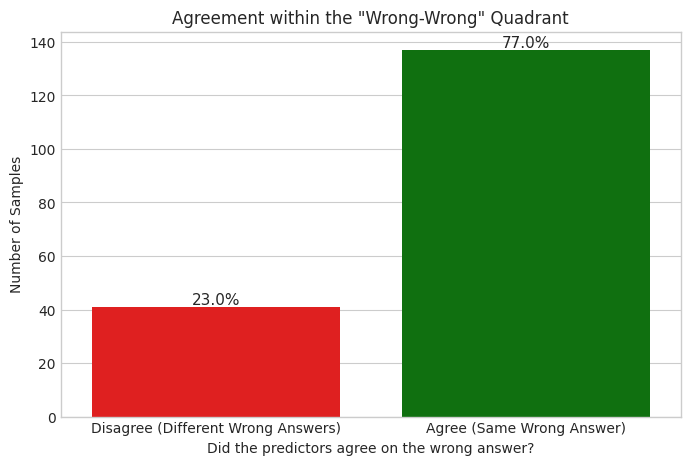

In [28]:
wrong_wrong_df = eval_df_all[
    (eval_df_all['text'] != eval_df_all['pred_text1']) &
    (eval_df_all['text'] != eval_df_all['pred_text2'])
].copy()

wrong_wrong_df['agreement_on_wrong'] = (
    wrong_wrong_df['pred_text1'] == wrong_wrong_df['pred_text2']
)

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=wrong_wrong_df,
    x='agreement_on_wrong',
    hue='agreement_on_wrong',
    palette=['Red', 'Green'],
    legend=False
)

plt.title('Agreement within the "Wrong-Wrong" Quadrant')
plt.ylabel('Number of Samples')
plt.xlabel('Did the predictors agree on the wrong answer?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree (Different Wrong Answers)', 'Agree (Same Wrong Answer)'])

# Add percentage annotations
total = len(wrong_wrong_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_354418/1012052540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


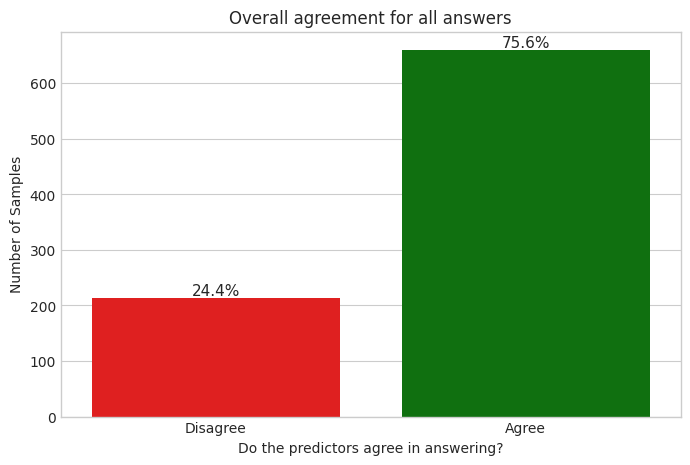

In [29]:
agreement_df = pd.DataFrame((eval_df_all['pred_text1'] == eval_df_all['pred_text2']), columns=['agreement'])

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=agreement_df,
    x='agreement',
    palette=['Red', 'Green']
)

plt.title('Overall agreement for all answers')
plt.ylabel('Number of Samples')
plt.xlabel('Do the predictors agree in answering?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree', 'Agree'])

# Add percentage annotations
total = len(agreement_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_354418/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_354418/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_354418/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_354418/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


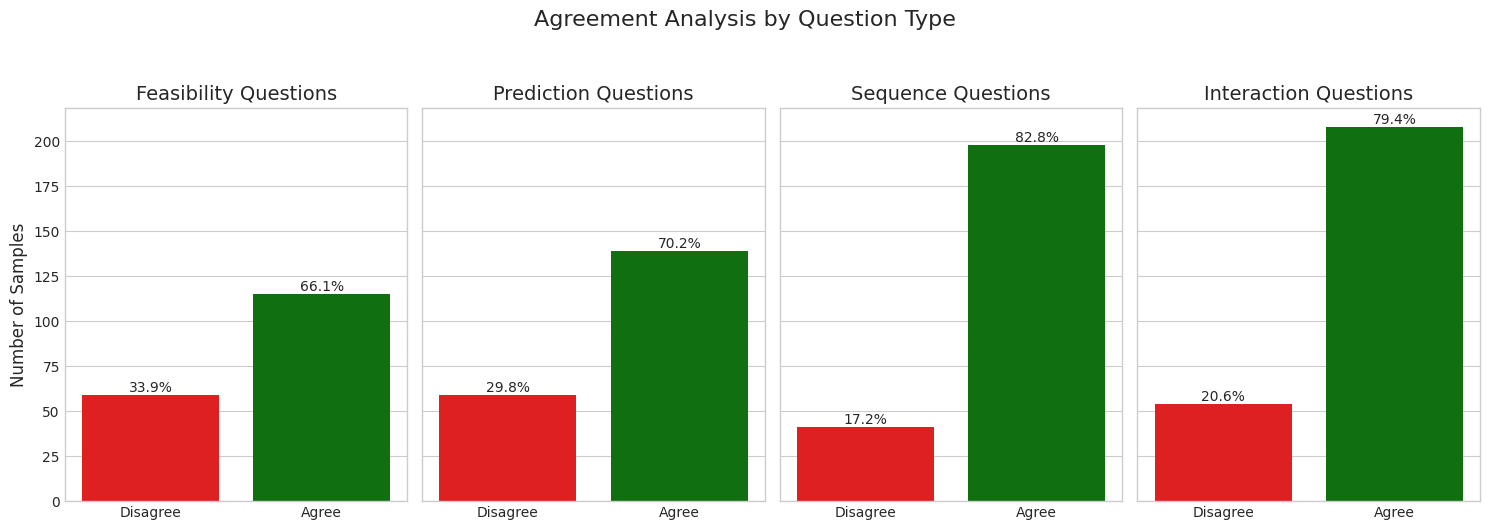

In [30]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Create agreement column in the copy
viz_df['agreement'] = viz_df['pred_text1'] == viz_df['pred_text2']

# Get unique question types
question_types = viz_df['question_type'].unique()
n_types = len(question_types)

# Create subplots
fig, axes = plt.subplots(1, n_types, figsize=(15, 5), sharey=True)
fig.suptitle('Agreement Analysis by Question Type', fontsize=16, y=1.05)

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Create countplot
    ax = sns.countplot(
        data=subset,
        x='agreement',
        palette=['Red', 'Green'],
        ax=axes[i]
    )
    
    # Set title and labels
    ax.set_title(f'{qtype} Questions', fontsize=14)
    ax.set_xlabel('')
    if i == 0:
        ax.set_ylabel('Number of Samples', fontsize=12)
    
    # Set x-ticks
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Disagree', 'Agree'])
    
    # Add percentage annotations
    total = len(subset)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [31]:
eval_df_all['pred_text1']


Feasibility_T5_1851               the laptop.
Prediction_T2_450                   put down.
Feasibility_T5_1670                 the dish.
Sequence_T5_4571                    put down.
Prediction_T1_499      sit on the sofa/couch.
                                ...          
Interaction_T1_8913       the paper/notebook.
Interaction_T1_8967                 the dish.
Interaction_T2_1847                     took.
Interaction_T2_3423                   sat on.
Interaction_T4_4181         put down the bag.
Name: pred_text1, Length: 873, dtype: object

## Inspection - 1


In [32]:
SHOW_VIDEO = True


In [33]:
vqa_correct_gqa_wrong_idxs = eval_df_all[
    (eval_df_all['text'] != eval_df_all['pred_text1'])
    & (eval_df_all['text'] == eval_df_all['pred_text2'])
].index.to_list()

print(len(vqa_correct_gqa_wrong_idxs))
print(f"{len(vqa_correct_gqa_wrong_idxs) / eval_df_all.shape[0]:.1%}")


64
7.3%


In [34]:
filtered = [v for v in vqa_correct_gqa_wrong_idxs if v in prev_analyzed]
filtered


[]

In [35]:
vqa_correct_gqa_wrong_idxs


['Feasibility_T6_720',
 'Feasibility_T4_78',
 'Feasibility_T5_1897',
 'Interaction_T2_7057',
 'Interaction_T1_6834',
 'Sequence_T4_3850',
 'Prediction_T2_1168',
 'Prediction_T1_2653',
 'Feasibility_T5_1965',
 'Prediction_T1_729',
 'Prediction_T2_22',
 'Interaction_T2_4564',
 'Prediction_T1_1583',
 'Prediction_T1_1992',
 'Interaction_T2_4605',
 'Feasibility_T5_1039',
 'Feasibility_T2_524',
 'Interaction_T3_2962',
 'Interaction_T4_4253',
 'Interaction_T2_3693',
 'Feasibility_T3_78',
 'Prediction_T2_875',
 'Sequence_T4_1402',
 'Feasibility_T6_1349',
 'Sequence_T5_1108',
 'Interaction_T3_5513',
 'Prediction_T4_968',
 'Feasibility_T5_981',
 'Prediction_T1_716',
 'Prediction_T3_580',
 'Sequence_T2_228',
 'Sequence_T6_4824',
 'Prediction_T1_738',
 'Feasibility_T6_938',
 'Prediction_T4_19',
 'Sequence_T3_4757',
 'Feasibility_T6_405',
 'Interaction_T4_1694',
 'Feasibility_T2_405',
 'Prediction_T3_945',
 'Feasibility_T5_552',
 'Interaction_T1_3722',
 'Feasibility_T6_448',
 'Prediction_T1_1273',


In [36]:
[i for i in vqa_correct_gqa_wrong_idxs if i[:2] == "Se"]


['Sequence_T4_3850',
 'Sequence_T4_1402',
 'Sequence_T5_1108',
 'Sequence_T2_228',
 'Sequence_T6_4824',
 'Sequence_T3_4757',
 'Sequence_T5_2354',
 'Sequence_T5_6072',
 'Sequence_T4_742',
 'Sequence_T2_3379',
 'Sequence_T3_312',
 'Sequence_T4_3501']

## Sample

### Text inspection

In [114]:
# idx = vqa_correct_gqa_wrong_idxs[0]
idx = "Sequence_T4_1402"
idx


'Sequence_T4_1402'

│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The phone/camera.
│    1. The food.
│    2. The laptop.
│    3. The bag.
│
│ Ground Truth:
│    The phone/camera.

In [115]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gqa_pred_df.rename(columns={'answer': 'pred_text'})])



┌─ Sample: Sequence_T4_1402 ────────────────────────────────────────────────────────────────
│
│ Question:
│    What happened before the person held the medicine?
│ Alternatives:
│    0. Took the dish.
│    1. Opened the box.
│    2. Threw the box.
│    3. Washed the window.
│
│ Ground Truth:
│    Opened the box.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│        Opened the box. [CORRECT]
│    Reasoning:
│        
│        1. **Question Interpretation:** The question asks to identify the action performed by the person immediately before they started holding the "medicine". Based on the context of the STSG, "white_and_blue_carton" appears to be the item being referred to as "medicine" due to the subsequent actions of opening/manipulating it and using a screwdriver on it, implying it's a package for some contents.
│        
│        2. **STSG Analysis:**
│            * **Frame 0-4:** The man is consuming contents from a spoon, holding a cylindrical container.
│           

In [116]:
print(gqa_pred_df.loc[idx]['chat_history'][0]['content'])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
man ---- wearing ---- polo_shirt
man ---- looking_at ---- hands
man ---- holding_in_left_hand ---- spoon
man ---- holding_in_right_hand ---- cylindrical_container
cylindrical_container ---- in_front_of ---- man
bottles_and_containers ---- on_top_of ---- surface
surface ---- to_the_left_of ---- man
</scene_graph>

Frame 1-3:
<scene_graph>
man ---- wearing ---- polo_shirt
man ---- looking_at ---- hands
man ---- holding_in_left_hand ---- spoon
man ---- holding_in_right_hand ---- cylindrical_container
man ---- manipulating ---- contents_in_spoon
man ---- manipulating ---- cylindrical_container
cylindrical_container ---- in_front_of ---- man
bottles_and_containers ---- on_top_of ---- surface
surface ---- to_the_left_of ---- man
</scene_graph>

Frame 4:
<scene_graph>
man ---- wearing ---- polo_shirt
man ---- bringing 

In [117]:
print(gqa_pred_df.loc[idx]['chat_history'][1]['content'])



1. **Question Interpretation:** The question asks to identify the action performed by the person immediately before they started holding the "medicine". Based on the context of the STSG, "white_and_blue_carton" appears to be the item being referred to as "medicine" due to the subsequent actions of opening/manipulating it and using a screwdriver on it, implying it's a package for some contents.

2. **STSG Analysis:**
    * **Frame 0-4:** The man is consuming contents from a spoon, holding a cylindrical container.
    * **Frame 5:** The man lowers his left hand and looks at items on a surface, specifically a "white_and_blue_carton".
    * **Frame 6:** The man extends his left hand and reaches for the "white_and_blue_carton".
    * **Frame 7-11:** The man picks up the "white_and_blue_carton" and holds it in both hands, then "opening_or_manipulating" it. This is the point where he starts holding the "medicine" (white_and_blue_carton).

3. **Alternative Evaluation:**
    *   **A. Took the 

In [118]:
print(gqa_pred_df.loc[idx]['chat_history'][3]['content'])



```json
{"answer": "B. Opened the box."}
```


#### VQA

In [119]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [vqa_pred_df.rename(columns={'answer': 'pred_text'})])



┌─ Sample: Sequence_T4_1402 ────────────────────────────────────────────────────────────────
│
│ Question:
│    What happened before the person held the medicine?
│ Alternatives:
│    0. Took the dish.
│    1. Opened the box.
│    2. Threw the box.
│    3. Washed the window.
│
│ Ground Truth:
│    Opened the box.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│        Took the dish. [WRONG]
│    Reasoning:
│        
│        Here's a detailed analysis of the video frames to answer your question:
│        
│        **1. Question Interpretation:**
│        The question asks to identify the action performed by the person *before* they held the medicine. The term "medicine" in the context of the video appears to refer to the various bottles and packages on the counter, specifically the one the person interacts with later in the sequence.
│        
│        **2. Video Analysis:**
│        Let's analyze the sequence of events shown in the provided frames:
│        
│        *   **

In [120]:
print(vqa_pred_df.loc[idx]['chat_history'][1]['content'])



Here's a detailed analysis of the video frames to answer your question:

**1. Question Interpretation:**
The question asks to identify the action performed by the person *before* they held the medicine. The term "medicine" in the context of the video appears to refer to the various bottles and packages on the counter, specifically the one the person interacts with later in the sequence.

**2. Video Analysis:**
Let's analyze the sequence of events shown in the provided frames:

*   **Frames 1-4:** The person is holding a small, round, orange-brown object in one hand and a spoon in the other. They appear to be scooping something from the orange-brown object with the spoon. There are several bottles and packages on the counter to their left.
*   **Frame 5:** The person brings the spoon to their mouth, suggesting they are consuming whatever was on the spoon. The small orange-brown object is still in their other hand.
*   **Frame 6:** The person has moved the small orange-brown object to t

In [121]:
print(vqa_pred_df.loc[idx]['chat_history'][-1]['content'])



```json
{"answer": "A. Took the dish."}
```


│    0. The phone/camera.
│    1. The laptop.
│    2. The book.
│    3. The food.

### Visual Inspection

#### Inspect frames

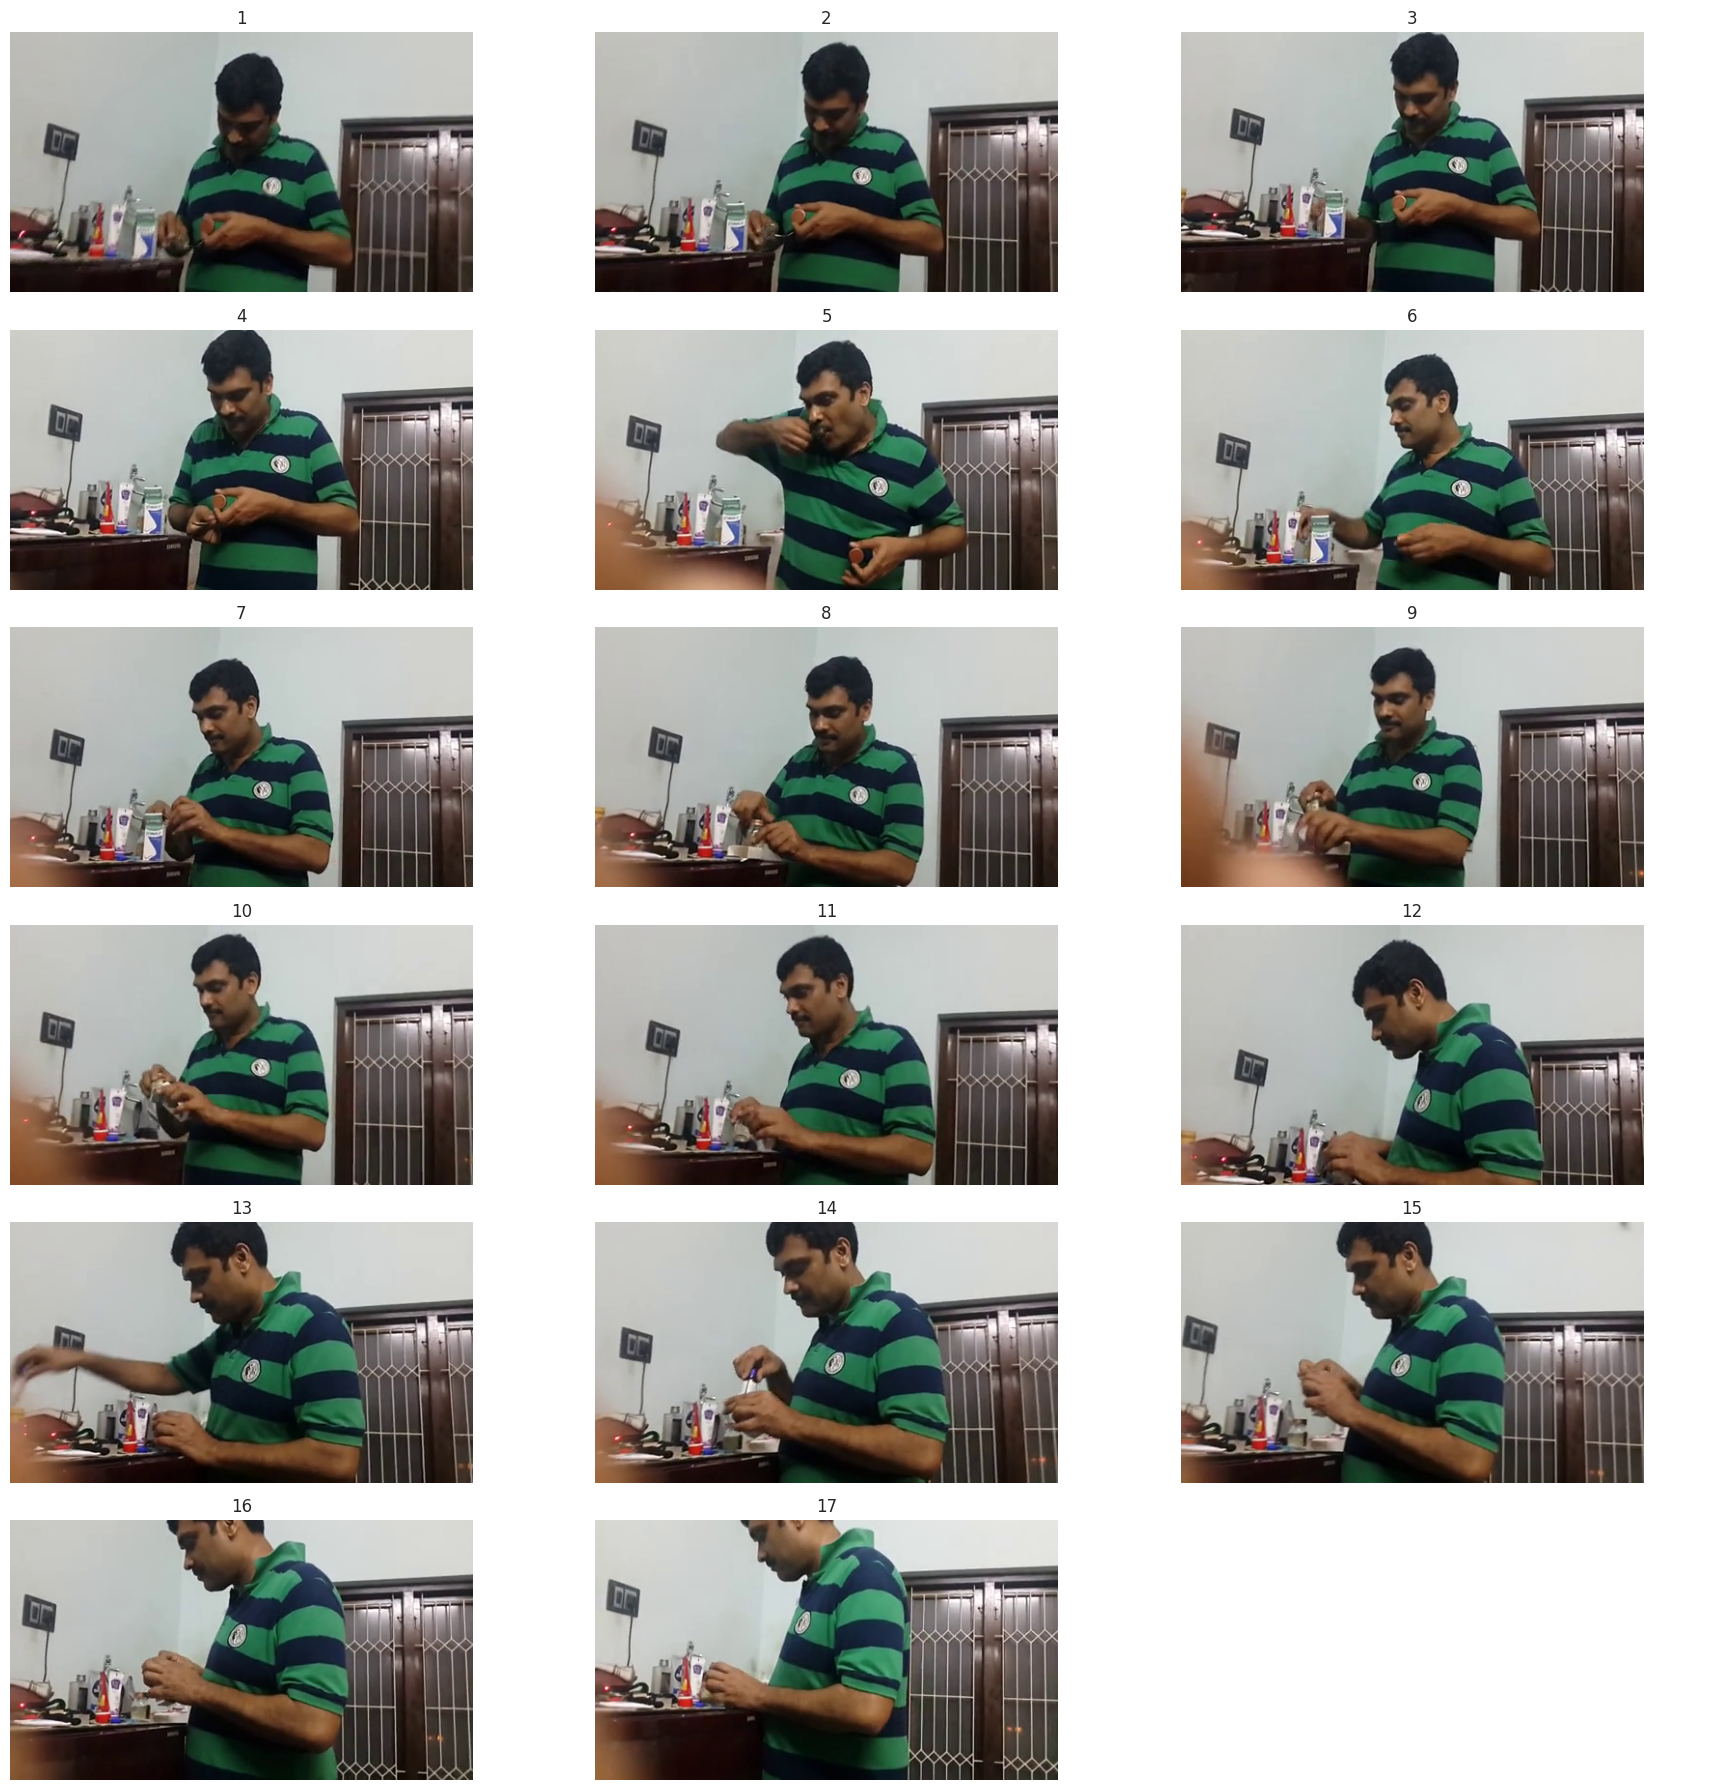

In [122]:
import math

frames_per_row = 3

if SHOW_VIDEO:
    video_path = RAW_VIDEO_DIR / f"{gt_df.loc[idx]['video_id']}.mp4"
    start = gt_df.loc[idx]['start']
    end = gt_df.loc[idx]['end']
    # values used in the experiments
    fps = 1
    max_frames = 64

    frame_dir, frame_paths = video_tools.extract_frames(
        video_path,
        fps=fps,
        max_frames=max_frames,
        start_time=start,
        end_time=end,
    )
    
    frames_per_row = min(frames_per_row, len(frame_paths))
    rows = math.ceil(len(frame_paths) / frames_per_row)
    
    images = frame_paths
    fig, axes = plt.subplots(rows, frames_per_row, figsize=(6*frames_per_row, 3*rows))
    axes = axes.flatten()
    
    for i, img_path in enumerate(images):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{i+1}")
        axes[i].axis('off')
    
    # Turn off the axes for any remaining subplots
    for i in range(len(images), len(axes)):
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()


#### Inspect the video

In [123]:
if SHOW_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


	Video Seg:  5.0s - 22.3s


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [124]:
gt_df.loc[idx]['video_id']


'MD6P2'